In [1]:
import torch
import torch.nn as nn

In [2]:
nn.Parameter( torch.ones( 4 )* (1.0/4) )

Parameter containing:
tensor([0.2500, 0.2500, 0.2500, 0.2500], requires_grad=True)

In [3]:
import math
math.pow(32/4,2)

64.0

In [4]:
x = torch.randn(2,3,32,32 )

In [5]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128):
        super().__init__()

        # TODO 1:
        # num_patches = ?
        self.num_patches = (img_size//patch_size)**2

        # TODO 2:
        # Conv2d: kernel=patch_size, stride=patch_size
        self.proj = nn.Conv2d(in_channels=in_chans, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: B,3,32,32

        # TODO 3:
        # conv
        x = self.proj(x) #B, N, 8, 8
        # TODO 4:
        # flatten spatial dims
        x = x.flatten(2)
        # TODO 5:
        # transpose to B,N,D
        x = x.transpose(1, 2)
        return x
patch_embed = PatchEmbed()
patch_embed(x).shape

torch.Size([2, 64, 128])

In [6]:
class MiniViT(nn.Module):
    def __init__(self):
        super().__init__()

        self.patch_embed = PatchEmbed()

        num_patches = self.patch_embed.num_patches
        embed_dim = 128

        # TODO 1:
        # cls_token (1,1,D)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # TODO 2:
        # pos_embed (1,N+1,D)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches+1, embed_dim))

    def forward(self,x):

        # B,N,D
        x = self.patch_embed(x)

        B = x.size(0)

        # TODO 3:
        # expand cls token to batch
        cls = self.cls_token.expand(B, -1, -1)

        # TODO 4:
        # concat cls + tokens
        x = torch.concat([cls, x], dim=1)

        # TODO 5:
        # add position embedding
        x += self.pos_embed

        return x
x = torch.randn(2,3,32,32)
model = MiniViT()
y = model(x)
print(y.shape)


torch.Size([2, 65, 128])


In [7]:
QKV = torch.randn(3,3,3)
q,k,v = torch.split(QKV, 1, dim=-1)
k.shape

torch.Size([3, 3, 1])

In [8]:
torch.matmul(q, k.transpose(-2,-1))

tensor([[[-0.2480, -0.1441, -0.0814],
         [-1.2652, -0.7351, -0.4155],
         [ 1.4776,  0.8585,  0.4852]],

        [[-0.4085, -0.2777,  0.9983],
         [ 0.5467,  0.3716, -1.3359],
         [ 0.4607,  0.3132, -1.1258]],

        [[ 0.2443, -0.4187, -0.3213],
         [-0.8461,  1.4502,  1.1130],
         [ 1.4075, -2.4126, -1.8516]]])

In [9]:
drop = nn.Dropout(0.1)
drop(q)

tensor([[[-0.2879],
         [-1.4684],
         [ 1.7150]],

        [[ 0.9569],
         [-1.2805],
         [-1.0791]],

        [[ 0.2976],
         [-1.0308],
         [ 0.0000]]])

In [14]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = 4
        self.head_dim = self.embed_dim//self.num_heads

        self.qkv = nn.Linear(embed_dim, embed_dim*3)
        self.projection = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x) #B,N,3D
        query, key, value = torch.split(qkv,D, dim=-1) #B,N,D

        query = query.reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        key = key.reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        value = value.reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3) #B, h, N, d

        attn_score = torch.softmax(torch.matmul(query, key.transpose(-2,-1))/math.sqrt(self.head_dim), dim=-1)
        attn_value = torch.matmul(attn_score, value)

        attn_value = attn_value.transpose(-2, -3).contiguous().reshape(B, N ,D)
        return self.dropout(self.projection(attn_value))

inputs = torch.randn(2, 65, 128)
model = MultiHeadSelfAttention()
model(inputs).shape

torch.Size([2, 65, 128])

In [15]:
t = ["1", "2", "3", "4"]
a = "123".join(t)
a

'1123212331234'

In [16]:
class Encoder(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim,eps=1e-5)
        self.norm2 = nn.LayerNorm(embed_dim,eps=1e-5)
        self.MLP = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*4, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = self.norm1(x)
        x += self.attention(x)
        x = self.norm2(x)
        x += self.MLP(x)
        return x
encoder = Encoder()
encoder(inputs).shape

torch.Size([2, 65, 128])

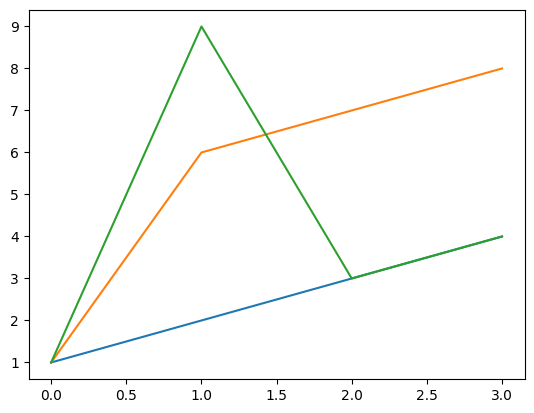

In [1]:
import matplotlib.pyplot as plt

a = [1,2,3,4]
b = [1,6,7,8]
c = [1, 9,3, 4]
plt.figure()
plt.plot(a)
plt.plot(b)
plt.plot(c)
plt.show()